In [1]:
from neuromaps import NeuroMapManuscript

model = NeuroMapManuscript.load("checkpoints/model.ckpt")

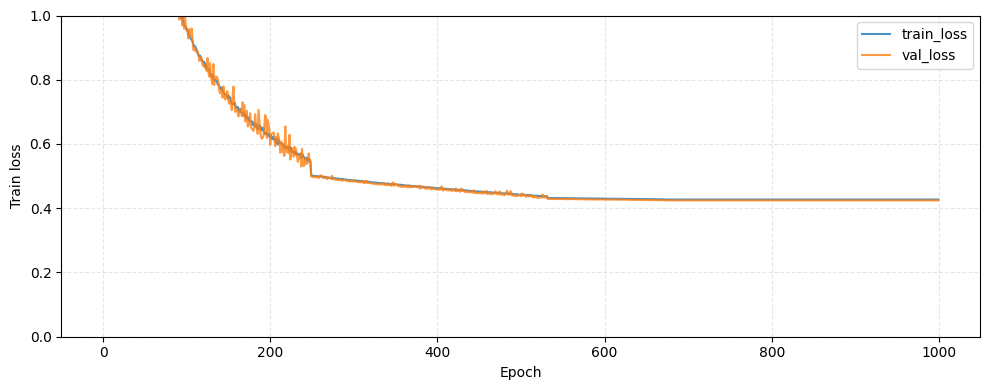

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use('default')
mpl.rcdefaults()

hist = model.training_history

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(np.arange(len(hist["train_loss"])), hist["train_loss"],
        label="train_loss", lw=1.5, alpha=.8)
ax.plot(np.arange(len(hist["val_loss"])), hist["val_loss"],
        label="val_loss", lw=1.5, alpha=.8)

ax.set_xlabel(f"Epoch")
ax.set_ylabel("Train loss")
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28364.53шаг/s]


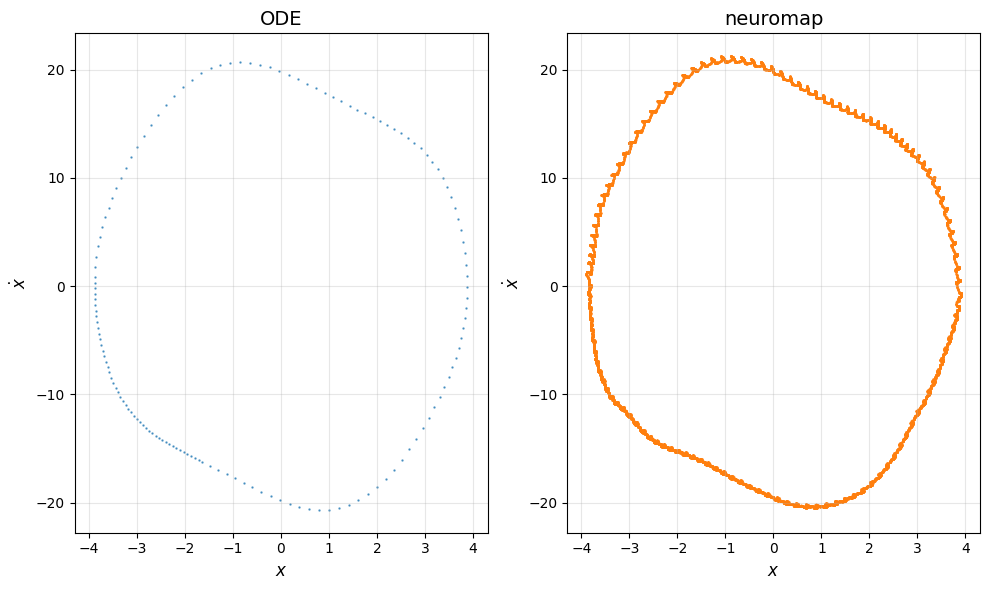

In [3]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [5, -50]
p = [-1.78, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

if nm_traj is not None:
    nm_traj = nm_traj[1000:]
if ode_traj is not None:
    ode_traj = ode_traj[100:]

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [26]:
from utils import grid_of_amplitude_basin_over_initial_state
from systems import vdp_mod1_rk4
import numpy as np

p_fixed = [-1.0, 0.07]
u0_base = [0.0, 0.0]
dt = 0.01
divergence_threshold = 1e5

x_grid = np.linspace(-10, 10, 100)
y_grid = np.linspace(-135, 135, 100)
x_state_index, y_state_index = 0, 1

Z_ode, div_ode = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=300,
    n_attractor=200,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    divergence_threshold=divergence_threshold,
    ode_amplitude_mode="secant",
    secant_plane=lambda x, y: x[1],
    secant_plane_derivatives=lambda x, y: [0, 1],
    right_part=vdp_mod1_right_part
)

Z_nm, div_nm = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=5000,
    n_attractor=5000,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    model=model,
    divergence_threshold=divergence_threshold,
)

Сетка по u0 (ODE, секущая): амплитуда + расходимость: 100%|██████████| 100/100 [27:44<00:00, 16.64s/it]
Сетка по u0 (Neuromap): амплитуда + расходимость:   0%|          | 0/100 [00:00<?, ?it/s]/Users/apanyushev/neuromap_sync/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Сетка по u0 (Neuromap): амплитуда + расходимость: 100%|██████████| 100/100 [21:55<00:00, 13.15s/it] 


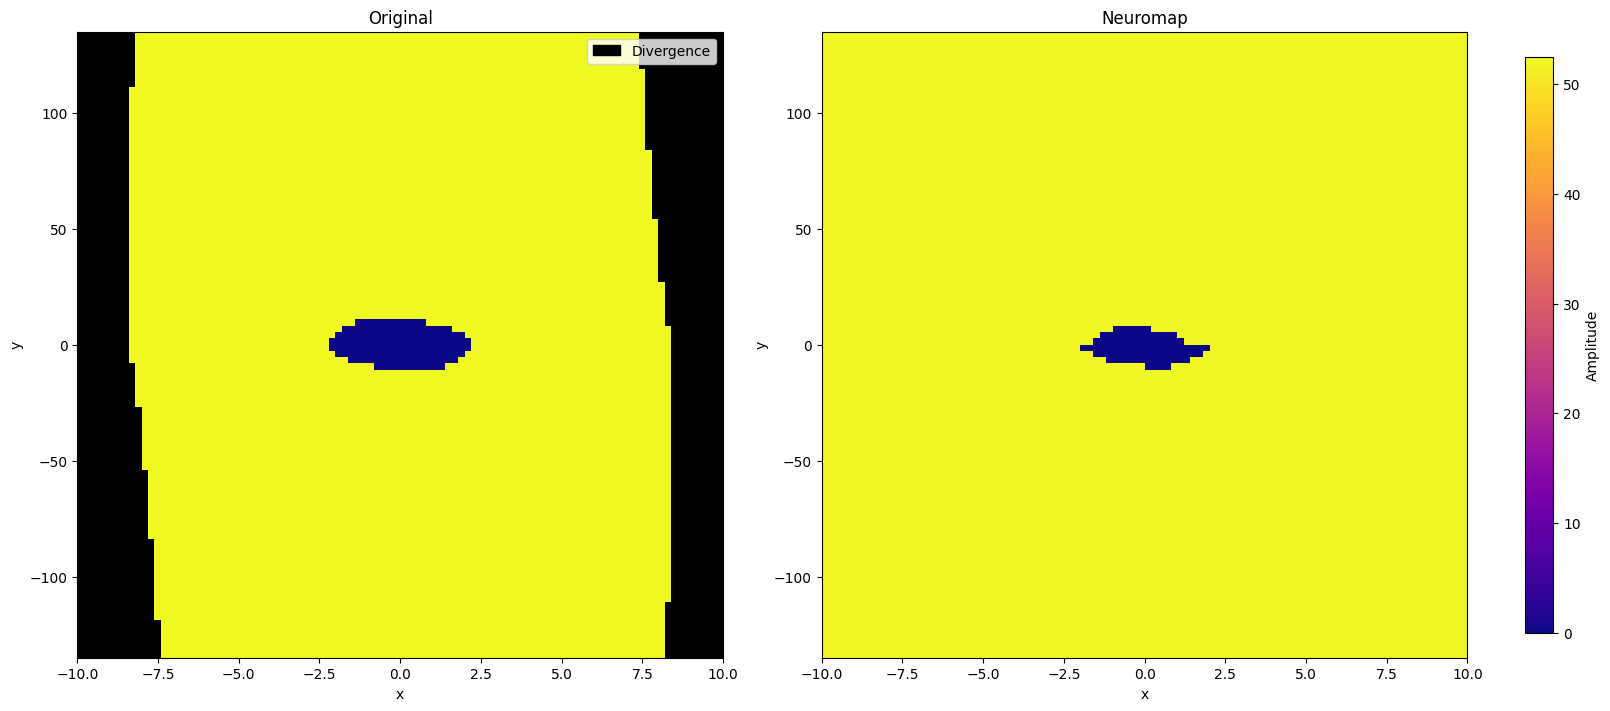

In [27]:
from utils import plot_amplitude_basin, plot_compare_amplitude_basins

plot_compare_amplitude_basins(
    x_grid,
    y_grid,
    Z_ode,
    Z_nm,
    x_label='x',
    y_label='y',
    cmap='plasma',
    bad_color='black',
)

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28377.58шаг/s]

2026-03-21 21:29:48 - neuromap_sync.plots - INFO - _plot_2d_trajectories:497 - ODE: divergence


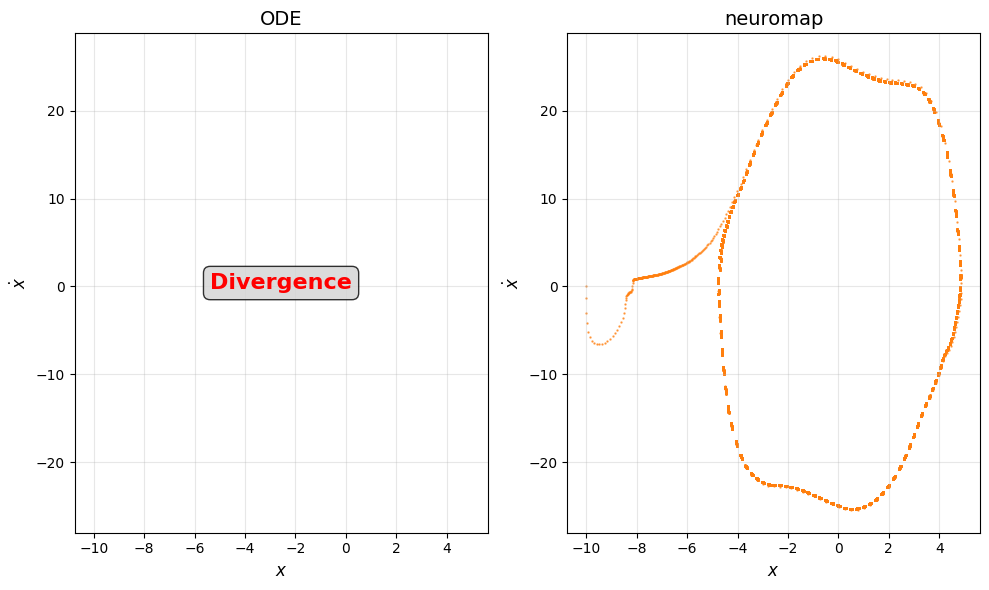

In [28]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [-10.0, 0.0]
p = [-1.0, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [ ]:
from utils import grid_of_fixed_point_probability_over_params, plot_heatmap

alpha_grid = np.linspace(-3.0, 1.0, 20)
beta_grid = np.linspace(0.02, 0.1, 20)

P = grid_of_fixed_point_probability_over_params(
    evolution_operator=None,
    model=model,
    state=[0.0, 0.0],
    params=[alpha_grid, beta_grid],
    dt=0.01,
    n_steps=4000,
    x_init_grid=np.linspace(-10, 10, 10),
    y_init_grid=np.linspace(-10, 10, 10),
    x_state_index=0,
    y_state_index=1,
    fixed_point_threshold=1e-4,
    divergence_threshold=1e5,
    n_jobs=-1,
)

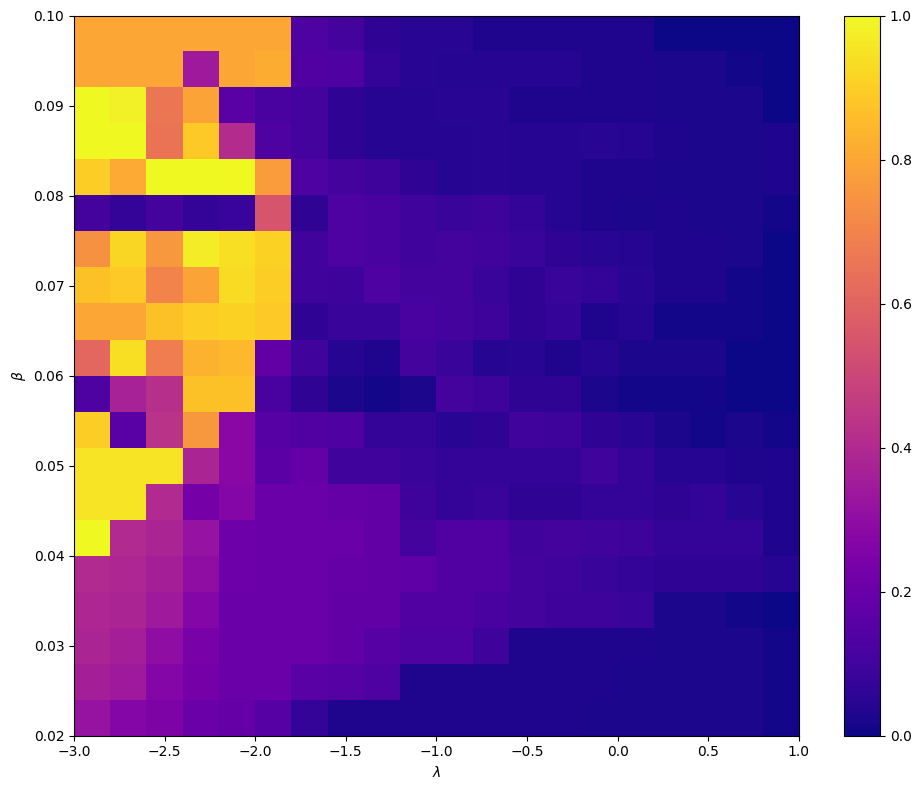

In [7]:
plot_heatmap(alpha_grid, beta_grid, P, x_label=r'$\lambda$', y_label=r'$\beta$')

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from utils.nn_map_fixed_points import grid_scan_neuromap_nearest_fixed_point

u0_u1 = np.linspace(-15, 15, 10)
u0_u2 = np.linspace(-35, 35, 10)

lam_grid = np.linspace(-3.0, 1.0, 40)
beta_grid = np.linspace(0.02, 0.1, 40)

dist_Z, log_rho_Z, xg, yg = grid_scan_neuromap_nearest_fixed_point(
    model,
    [lam_grid, beta_grid],
    (u0_u1, u0_u2),
    n_jobs=-1,
    residual_tol=1e-7,
    unique_tol=1e-3,
)

Скан неподвижных точек (nearest ||u||): 100%|██████████| 40/40 [02:38<00:00,  3.96s/it]


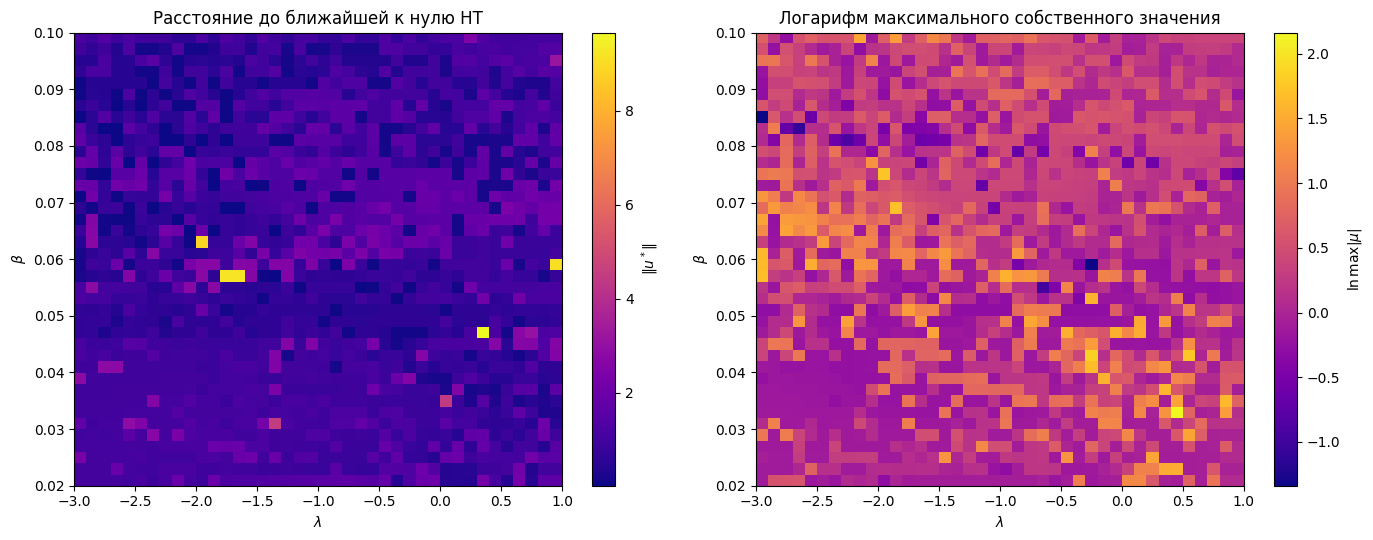

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()

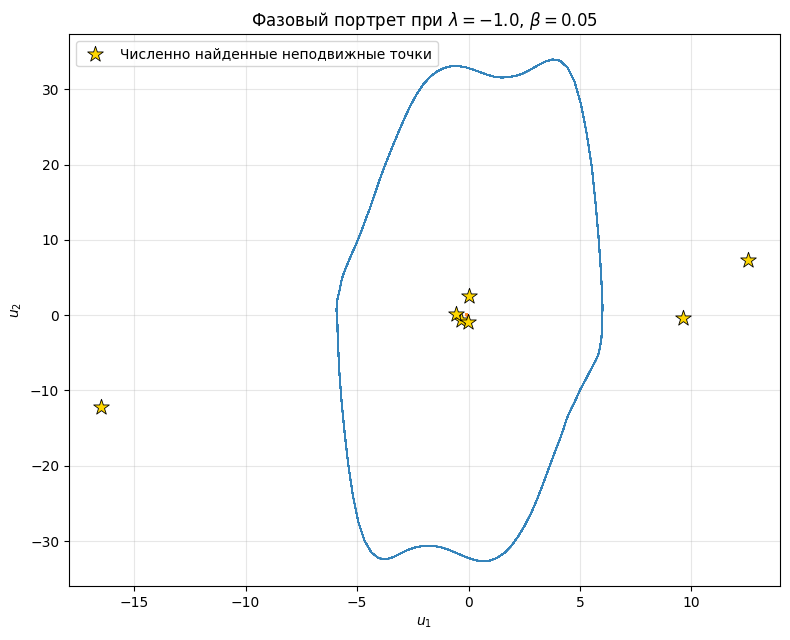

Найдено уникальных НТ: 7
  #0: u = [-16.47727029 -12.1448036 ], ||u|| = 20.4694
  #1: u = [-0.36027808 -0.59113095], ||u|| = 0.692269
  #2: u = [-0.57169671  0.09520643], ||u|| = 0.57957
  #3: u = [0.0269112  2.51801193], ||u|| = 2.51816
  #4: u = [-0.03409374 -0.9610181 ], ||u|| = 0.961623
  #5: u = [ 9.61479929 -0.37782613], ||u|| = 9.62222
  #6: u = [12.520595    7.28371947], ||u|| = 14.4851


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from utils.nn_map_fixed_points import collect_fixed_points_grid_starts

# --- фиксированные параметры карты (λ, β); измените при необходимости ---
lam, beta = -1.0, 0.05
p_fixed = [float(lam), float(beta)]
p_2d = np.array([[lam, beta]], dtype=np.float64)

# --- поиск неподвижных точек: декартово произведение осевых сеток стартов ---
u0_u1 = np.linspace(-15.0, 15.0, 12)
u0_u2 = np.linspace(-35.0, 35.0, 12)
fixed_pts = collect_fixed_points_grid_starts(
    model,
    p_fixed,
    (u0_u1, u0_u2),
    residual_tol=1e-7,
    unique_tol=1e-3,
)

# --- начальные условия: список пар (u1, u2) ---
initial_conditions = [
    (5.0, 20.0),
    (0.0, 0.5),
]

n_steps = 8000
n_transient = 1000  # отбросить первые шаги перед отрисовкой

fig, ax = plt.subplots(figsize=(8, 6.5))
for u1, u2 in initial_conditions:
    u0 = np.array([[u1, u2]], dtype=np.float64)
    traj = model.simulate(u0, p_2d, n_steps, verbose=False)
    if traj is None:
        ax.plot([u1], [u2], "rx", ms=8, label="_nolegend_")
        continue
    traj = traj[n_transient:]
    if len(traj) < 2:
        continue
    ax.plot(traj[:, 0], traj[:, 1], lw=0.9, alpha=0.9)

if fixed_pts:
    fp = np.stack([np.asarray(u, dtype=float).ravel() for u in fixed_pts], axis=0)
    ax.scatter(
        fp[:, 0],
        fp[:, 1],
        s=140,
        marker="*",
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=6,
        label="Численно найденные неподвижные точки",
    )
else:
    ax.text(
        0.02,
        0.98,
        "НТ не найдены (см. сетку стартов / residual_tol)",
        transform=ax.transAxes,
        va="top",
    )

ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_2$")
ax.set_title(rf"Фазовый портрет при $\lambda={lam}$, $\beta={beta}$")
ax.grid(True, alpha=0.3)
if fixed_pts:
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Найдено уникальных НТ: {len(fixed_pts)}")
for i, u in enumerate(fixed_pts):
    print(f"  #{i}: u = {np.asarray(u).ravel()}, ||u|| = {np.linalg.norm(u):.6g}")

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from utils.nn_map_fixed_points import grid_scan_neuromap_nearest_fixed_point

u0_u1 = np.linspace(-15, 15, 10)
u0_u2 = np.linspace(-35, 35, 10)

lam_grid = np.linspace(-3.0, 1.0, 40)
beta_grid = np.linspace(0.02, 0.1, 40)

dist_Z, log_rho_Z, xg, yg = grid_scan_neuromap_nearest_fixed_point(
    model,
    [lam_grid, beta_grid],
    (u0_u1, u0_u2),
    n_jobs=-1,
    residual_tol=1e-10,
    unique_tol=1e-3,
)

Скан неподвижных точек (nearest ||u||), корни: 100%|██████████| 40/40 [02:47<00:00,  4.18s/it]


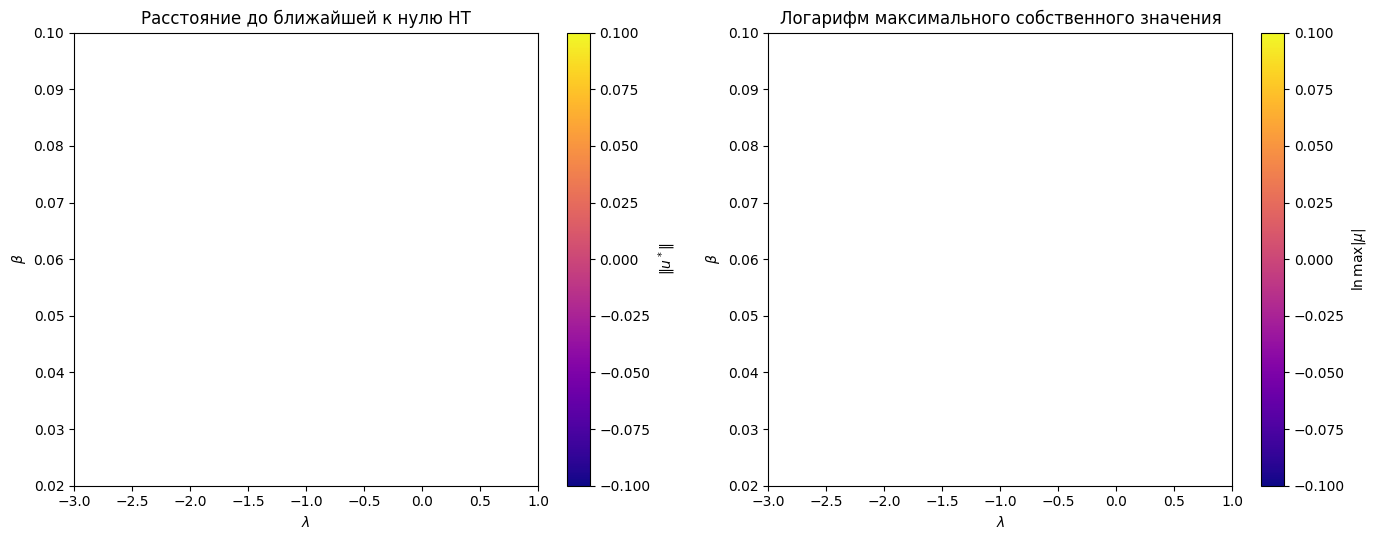

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from utils.nn_map_fixed_points import grid_scan_neuromap_nearest_fixed_point

u0_u1 = np.linspace(-15, 15, 10)
u0_u2 = np.linspace(-35, 35, 10)

lam_grid = np.linspace(-3.0, 1.0, 40)
beta_grid = np.linspace(0.02, 0.1, 40)

dist_Z, log_rho_Z, xg, yg = grid_scan_neuromap_nearest_fixed_point(
    model,
    [lam_grid, beta_grid],
    (u0_u1, u0_u2),
    n_jobs=-1,
    residual_tol=1e-8,
    unique_tol=1e-3,
)

Скан неподвижных точек (nearest ||u||), корни: 100%|██████████| 40/40 [03:09<00:00,  4.73s/it]


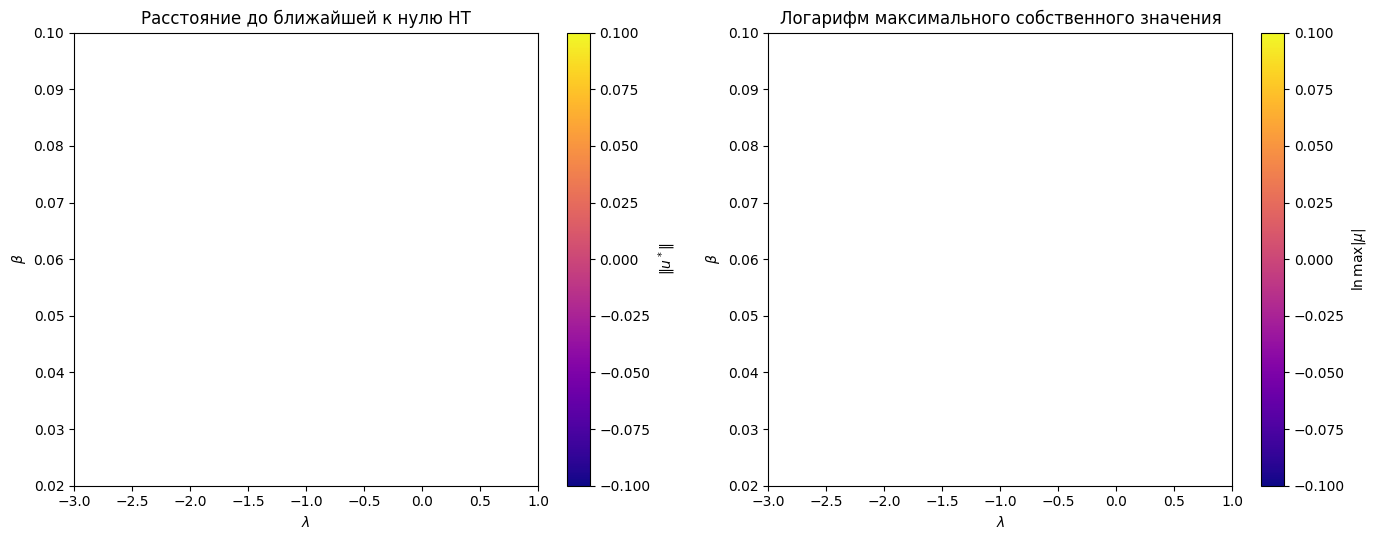

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, Z, ttl, clab in (
    (axes[0], dist_Z, r"Расстояние до ближайшей к нулю НТ", r"$\|u^*\|$"),
    (axes[1], log_rho_Z, r"Логарифм максимального собственного значения", r"$\ln\max|\mu|$"),
):
    im = ax.imshow(
        Z,
        extent=[xg[0], xg[-1], yg[0], yg[-1]],
        origin="lower",
        aspect="auto",
        interpolation="nearest", 
        cmap="plasma",
    )
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(ttl)
    fig.colorbar(im, ax=ax, label=clab)
plt.tight_layout()
plt.show()